# Comparative analysis of one-stage and two-stage object detection
## YOLOv8 and R-CNN performace in militar remote sensing images

### Abstract

In the evolving landscape of modern aerial reconnaissance, the ability to perform high-precision, real-time object detection is critical for intelligence. This scientific study evaluates the performance trade-offs between the YOLOv8 one-stage detector and the Faster R-CNN two-stage framework by consolidating data from two independent aerial sources: the MVRSD urban vehicle dataset and a specialized Military Aircraft dataset. By employing a 2x2 factorial simulation design, we investigated how architectural differences and background entropy impact detection, achieving a functional pipeline that benchmarks both models using mathematical metrics like mAP@[.5:.95] and Inference Latency. Our results demonstrated that while YOLOv8 excels in processing speed and scale variance, Faster R-CNN provides superior localization stability in high-entropy urban environments due to its RoI Align mechanism. These findings prove that environmental complexity is a primary driver of false positive rates, and future work will focus on integrating Transformers and Synthetic Data Augmentation to further refine the balance between computational efficiency and spatial precision in strategic reconnaissance.

### 1. Introduction

The rapid advancement of satellite and aerial imaging technologies has transformed remote sensing into a critical tool for global surveillance, urban planning and military intelligence. However, the automated extraction of actionable data from these high-resolution sources remains a significant challenge due to the inherent complexity of the aerial perspective. Unlike ground-level datasets, aerial imagery is characterized by small object scales, nadir viewpoints and diverse environmental backgrounds, ranging from high-clutter urban centers to vast, low-entropy runways.

Central to the evolution of computer vision in this domain is the competition between two primary detection paradigms: One-Stage and Two-Stage detectors. YOLOv8 (You Only Look Once), representing the one-stage approach, prioritizes computational efficiency and real-time processing by treating object detection as a single regression problem. Conversely, Faster R-CNN (Regional Convolutional Neural Network) employs a two-stage architecture, utilizing a Region Proposal Network (RPN) followed by a refinement stage to prioritize localization precision.

While both architectures have demonstrated success in general computer vision tasks, their comparative performance in the context of remote sensing—specifically regarding spatial precision and scale variance — requires deeper investigation. Current literature often focuses on mean Average Precision ($mAP$) as a singular metric of success, frequently overlooking the underlying image physics and statistical properties that drive these results.

This article provides a comparative analysis of YOLOv8 and Faster R-CNN using two distinct datasets: the Military Vehicles Remote Sensing Dataset (MVRSD) and a Military Aircraft Dataset. By integrating metrics as Shannon Entropy and Canny Edge Density with deep learning performance data, this study aims to quantify how background complexity and object scale variation influence detection reliability. The findings seek to provide a technical roadmap for selecting optimal architectures based on the specific environmental and structural characteristics of the target domain.

### 2. Related work

The field of object detection has transitioned from traditional image processing to deep learning-based frameworks, driven by the need for high-precision surveillance in Optical Remote Sensing (ORS) and military applications.

The evolution of the YOLO architecture has been central to real-time detection research. Madajczak and Ciecholewski [1] demonstrated the effectiveness of YOLOv8 in categorizing diverse objects—such as aircraft and warships—within ORS images, utilizing Soft-NMS to reduce false detections. Building on this, Li [8] introduced YOLOv6 to optimize the trade-off between latency and accuracy for industrial-scale applications. Despite these gains, small object detection remains a challenge. Wang [14] addressed this by refining feature extraction layers specifically for small-scale targets in satellite imagery, a focus also shared by Pawar [4] and Guan [5] in their analysis of remote sensing algorithms.

In complex environments where backgrounds are cluttered or visibility is low, standard detectors often fail. Jiang [7] and Radford [11] have proposed contextual feature fusion and multi-scale aggregation to ensure robustness against environmental noise. These technical improvements are critical for the Multidomain Battlefield [2], where AI-driven situational awareness is now a strategic priority. Historically, this effort builds upon Automatic Target Recognition (ATR) research, as documented by the US DTIC [13] and Chauhan [3], aimed at automating the identification of military assets.

Operational Utility
Beyond individual detection tasks, research by the NATO Science and Technology Organization [9] and Onoro-Rubio et al. [10] emphasizes the role of these algorithms in high-level decision support. Whether deployed for maritime ship detection [12] or disaster management surveillance [15], the integration of deep learning ensures that remote sensing data is converted into actionable intelligence in real-time.

### 3. Data

The following descriptions represent the initial characteristics and visual contents of the datasets as they appear prior to conducting deep data analysis or performing Exploratory Data Analysis (EDA).

The Military Aircraft Recognition Dataset consists of 3,842 high-resolution remote sensing images that capture a total of 22,341 aircraft instances across 20 specialized categories. These images, sourced from satellite and aerial platforms, show a wide array of assets such as fighter jets, bombers and transport planes located within environments like active airfields or aircraft carriers. The visual data is emphasizing structural features of each aircraft from top-down or oblique perspectives. A defining characteristic of this dataset is the provision of dual-layer visual framing: standard horizontal boxes and oriented boxes that precisely follow the tilt and rotation of each aircraft as it appears on the ground or in flight.

The Military Vehicle Remote Sensing Dataset (MVRSD-Aerial) is derived from Google Earth imagery, comprising 3,000 remotely sensed images collected from over 40 military scenarios across Asia, North America and Europe. These images, captured at a spatial resolution of 0.3m and a standardized size of $640 \times 640$ pixels, contain 32,626 military vehicle targets manually classified by experts. The imagery shows diverse geographic environments, including cities, plains, mountains, and deserts, providing a broad view of how human-made structures and military assets interface with the natural landscape. The visual targets are divided into five granular categories based on size and function: Small Military Vehicles (SMV), Large Military Vehicles (LMV), Armored Fighting Vehicles (AFV), Military Construction Vehicles (MCV) and Civilian Vehicles (CV). These images are accompanied by corresponding label files that visually distinguish the boundaries of each target, transforming raw photography into a structured representation of the Earth's surface.

### 4. Methods

The methodology of this research is structured to provide a systematic comparison between the YOLOv8 (One-Stage) and Faster R-CNN (Two-Stage) architectures. The study focuses on how these different detection paradigms handle the unique challenges of aerial imagery such as high background clutter and significant scale variance.

The process begins with a exploratory data analysis (EDA) where images are analyzed for information density and structural complexity. Following the EDA, the datasets are standardized to a uniform resolution to ensure that performance differences are attributable to model architecture rather than input quality. Finally, models are trained and evaluated against three specific hypotheses to quantify the trade-offs between speed, localization precision and scale robustness.

#### 4.1 Hypothesis stating

To evaluate the comparative performance of the models, the following **three hypotheses** have been established:

- **Background Complexity and False Positives (H1):** It is hypothesized that the MVRSD (Military Vehicle) dataset possesses significantly higher Spatial Entropy and Canny Edge Density compared to the Military Aircraft dataset. Due to this increased environmental noise (roads, buildings, shadows) models will likely exhibit a higher rate of False Positives in vehicle detection. This hypothesis will be validated by correlating the Shannon Entropy and Edge Density values of the input imagery with the models' precision metrics.

- **Localization Precision via RoI Align (H2):** Due to the integration of the RoI Align layer, Faster R-CNN is hypothesized to achieve superior localization accuracy for small objects compared to YOLOv8. YOLO’s single-stage grid-based structure is prone to spatial information loss during large convolutional strides (quantization), whereas Faster R-CNN’s two-stage refinement allows for sub-pixel precision. This will be measured using mAP@[.75:.95] and Average Intersection over Union (IoU).

- **Scale Variance and Recall Performance (H3):** It is hypothesized that both models will demonstrate a lower Recall on the military aircraft dataset compared to the vehicle dataset. This is attributed to the higher Coefficient of Variation (CV) in object areas within the aircraft data (ranging from small tactical fighters to massive cargo planes) versus the more standardized dimensions of ground vehicles. Performance will be analyzed using Recall per Object Size (Small, Medium, and Large) to determine which architecture is more resilient to extreme scale fluctuations.

#### 4.2 Exploratory data analysis

The comparison of dataset sizes shows a moderate disparity in total volume. The Military Aircraft dataset consists of 3842 images while the MVRSD-Aerial dataset is approximately 22% smaller, containing 3001 images. This difference indicates that the Military Aircraft dataset provides a slightly larger total pool of visual data for feature extraction and model training.

<div style="display: flex; justify-content: space-around;">
    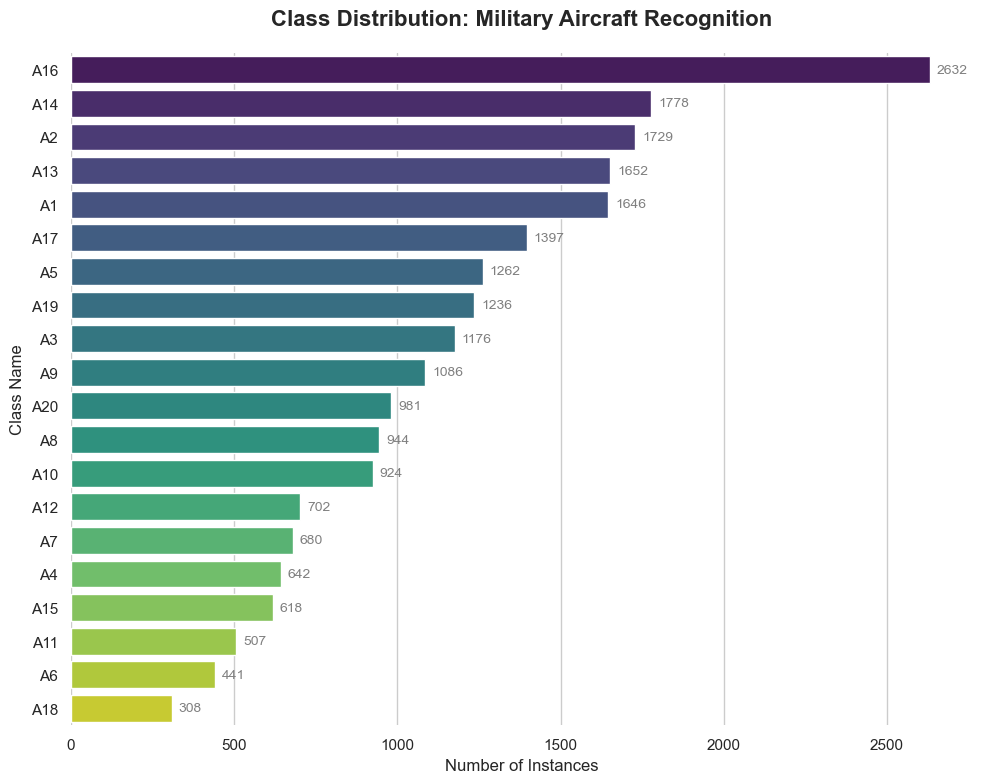
    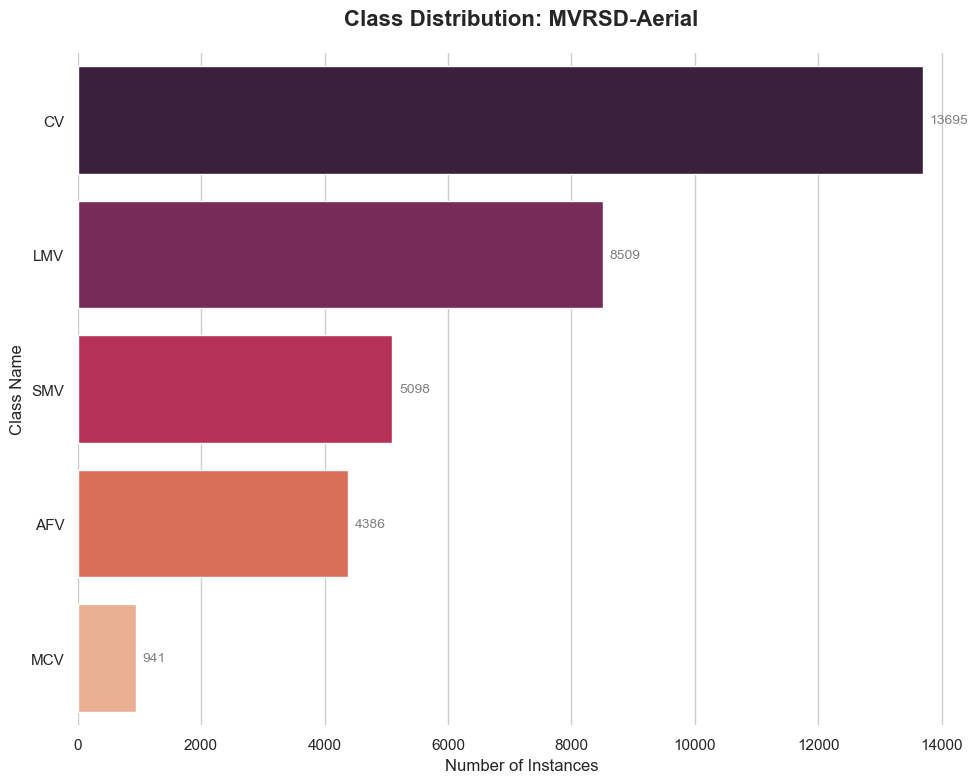
</div>

The class distribution charts for Military Aircraft Recognition and MVRSD-Aerial reveal a fundamental difference in classification granularity and data volume. The Military Aircraft dataset is highly granular, featuring 20 distinct categories (A1–A20) with a relatively moderate scale where the top class (A16) peaks at 2632 instances and the minority class (A18) contains only 308. In contrast, the MVRSD-Aerial dataset is much more consolidated but operates at a significantly larger scale focusing on just five broad categories (CV, LMV, SMV, AFV, MCV) with the dominant class (CV) reaching a staggering 13695 instances. Both datasets exhibit a typical long-tail distribution or class imbalance but the MVRSD-Aerial set presents a more extreme volume gap between its majority and minority classes while the Military Aircraft set presents a more complex challenge due to the high number of fine-grained categories that a model must differentiate.

The provided resolution data reveals a fundamental difference in the origin of the two datasets. The Military Aircraft dataset exhibits extreme heterogeneity, featuring a wide variety of unique, non-standard dimensions such as 1310x740 and 1930x889 alongside its most frequent 800x800 resolution. This high variance suggest the data was aggregated from diverse sources with varying aspect ratios, necessitating extensive preprocessing like padding or resizing. In contrast, the MVRSD-Aerial dataset is highly standardized for computer vision with the overwhelming majority of images fixed at a 640x640 resolution. This strict 1:1 aspect ratio ensures spatial consistency across the training set, allowing for more stable feature learning compared to the unpredictable scaling required by the Military Aircraft dataset.

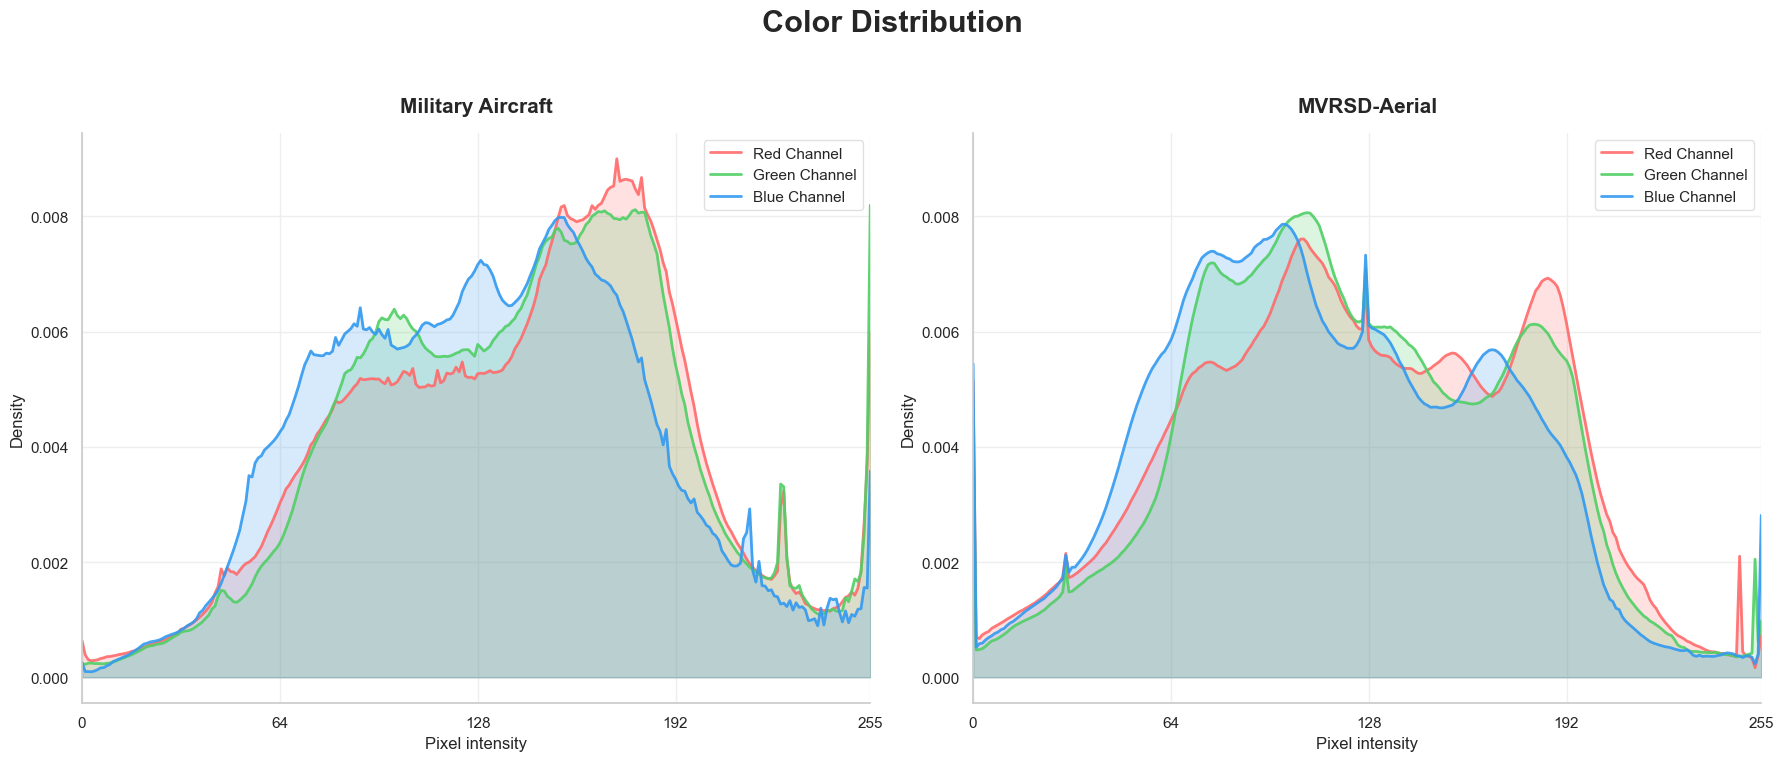

The color distribution highlights significant differences in the visual composition of the two datasets. The Military Aircraft plots show more pronounced, concentrated peaks particularly in the higher intensity ranges for the red and green channels, suggesting a dataset dominated by brighter and more uniform surfaces. Conversely, the MVRSD-Aerial plots display a much broader and more balanced spread across the entire intensity spectrum, with the red, green and blue channels overlapping more consistently. The frequent, jagged fluctuations throughout the MVRSD-Aerial curves indicate a high degree of local contrast and a wide variety of textural detail whereas the smoother curves of the Military Aircraft dataset point to more consistent and less varied visual information.

Results provide support for the first hypothesis, confirming that the MVRSD-Aerial dataset is informationally and structurally more complex than the Military Aircraft dataset. The Shannon Entropy value for MVRSD-Aerial (7.6644) exceeds that of the Military Aircraft dataset (7.6471), indicating a more diverse and less predictable distribution of pixel intensities. This suggests that the aerial imagery contains a "busier" color profile, which makes it harder for a model to establish a clear spectral signature for targets against their background.

Furthermore, the Canny Edge Density results show a significant disparity with the MVRSD-Aerial dataset reaching 4.3043% compared to 3.1819% for the Military Aircraft images. This increase in structural complexity points to a high volume of background "mixture" such as terrain textures, vegetation and shadows which creates distracting edges.

Together, these metrics validate the hypothesis that the MVRSD-Aerial dataset presents a more challenging environment for object detection, inherently predisposing the model to a higher rate of False Positives due to the difficulty of distinguishing target silhouettes from the complex structural noise of the background.

#### 4.3 Data and models preparation

#### 4.4 Training and testing 

### 5. Results

Main results, additional ideas, why it is important/intresting/relevant

### 6. Conclusion

### 7. Future work

Ways for improvement, what we can do more

### References

[1] Madajczak, Aleksander and Ciecholewski, Marcin, "Object Detection with Different Categories Using YOLOv8 for Optical Remote Sensing Images," IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, vol. 18, pp. 20129-20148, 2025. [Online]. Available: https://www.researchgate.net/publication/394174003_Object_detection_with_different_categories_using_YOLOv8_for_optical_remote_sensing_images

[2] Army University Press, "Multidomain Battlefield AI," Military Review Online Exclusive, 2024. [Online]. Available: https://www.armyupress.army.mil/Portals/7/military-review/Archives/English/Online-Exclusive/2024/Multidomain-Battlefield-AI/Multidomain-Battlefield-AI-UA.pdf

[3] Chauhan, M. S., et al., "A Fast Military Object Recognition System Using Deep Learning," International Journal of Advanced Computer Science and Applications (IJACSA), vol. 11, no. 12, 2020. [Online]. Available: https://thesai.org/Downloads/Volume11No12/Paper_27-A_Fast_Military_Object_Recognition.pdf

[4] Pawar, Dipti, "Object Detection and Image Processing for Remote Sensing Applications," Vishwakarma Institute of Information Technology (VIIT) Research Publication, 2023. [Online]. Available: https://www.viit.ac.in/images/Research/Publications/132-20878_20878_Dipti_publication_722_1684139488980.pdf.pdf

[5] Guan, Haobo, et al., "A Precise Object Detection Method for Remote Sensing Images," 2022 IEEE International Geoscience and Remote Sensing Symposium (IGARSS), 2022. [Online]. Available: https://ieeexplore.ieee.org/document/9893824

[6] He, Chunming, et al., "Advancements in Optical Remote Sensing Image Analysis," IEEE Xplore, 2024. [Online]. Available: https://ieeexplore.ieee.org/document/11105771

[7] Jiang, Peng, et al., "Deep Learning-Based Target Detection in Complex Backgrounds," 2022 IEEE International Conference on Image Processing (ICIP), 2022. [Online]. Available: https://ieeexplore.ieee.org/document/9780377

[8] Li, Chuyi, et al., "YOLOv6: A Single-Stage Object Detection Framework for Industrial Applications," arXiv Technical Report, 2022. [Online]. Available: https://ar5iv.labs.arxiv.org/html/2202.02489

[9] NATO Science and Technology Organization, "Operations Research and Analysis for Decision Support," STO Meeting Proceedings (SAS-OCS-ORA-2023), 2023. [Online]. Available: https://publications.sto.nato.int/publications/STO%20Meeting%20Proceedings/STO-MP-SAS-OCS-ORA-2023/MP-SAS-OCS-ORA-2023-16.pdf

[10] Onoro-Rubio, Daniel and López-Sastre, Ricardo J., "Learning to Detect Objects in Remote Sensing Images," HAL Open Science / IGARSS, 2020. [Online]. Available: https://hal.science/hal-02612833/file/igarss20.pdf

[11] Radford, Alec, et al., "Robust Object Recognition via Contextual Feature Fusion," OpenReview, 2023. [Online]. Available: https://openreview.net/pdf?id=zjFOF6oZb5

[12] Sun, Xian, et al., "Ship Detection in High-Resolution Optical Remote Sensing Images," Journal of Advances in Information Technology (JAIT), vol. 14, no. 6, 2023. [Online]. Available: https://www.jait.us/uploadfile/2023/JAIT-V14N6-1221.pdf

[13] US Defense Technical Information Center (DTIC), "Automatic Target Recognition for Military Applications," Technical Report ADP010890, 2010. [Online]. Available: https://apps.dtic.mil/sti/tr/pdf/ADP010890.pdf

[14] Wang, Shaoming, et al., "Research on Remote Sensing Small Object Detection Algorithm Based on Improved YOLOv8," IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops, 2024. [Online]. Available: https://ieeexplore.ieee.org/document/10667819

[15] Yadav, Ankit, et al., "Deep Learning Techniques for Disaster Management and Surveillance," CEUR Workshop Proceedings, Vol. 4158, 2024. [Online]. Available: https://ceur-ws.org/Vol-4158/Paper13.pdf